# Machine learning on CTA data with hexagonal CNNs

A complete, self-contained example: train a **3-D hexagonal CNN** (space + time)
to tell a **gamma-ray air-shower** apart from **night-sky-background (NSB) noise**
in a Cherenkov telescope camera.

Everything is streamed from the internet, so this runs anywhere:

* the **camera geometry** (LST camera, 1855 hexagonal pixels) comes from
  [`ctapipe`](https://ctapipe.readthedocs.io) via `CameraGeometry.from_name`;
* the **simulated events** (raw per-pixel waveforms) come from ctapipe's public
  sample data;
* the **hexagonal convolution / pooling** layers come from
  [`keras-hexagdly`](https://github.com/YugnatD/keras-hexagdly)
  (`pip install keras-hexagdly`), a Keras 3 port of
  [HexagDLy](https://github.com/ai4iacts/hexagdly).

The pipeline, per event:

```
raw waveform  (1855 pixels x 30 time samples)
   -> scatter each time frame onto a 2-D hex grid   -> (T, H, W, 1)
   -> hexagonal Conv3d over (time x hex neighbourhood, depth-"same")
   -> global max over time AND camera                -> one score per filter
   -> dense head -> P(gamma)
```

> **This is a didactic example.** The public sample file has only ~70 real LST
> events, and we use a deliberately simple synthetic NSB-noise model, so the
> task is easy (you'll see a near-perfect score). The goal is to show the *full
> real-data pipeline* end-to-end; the "Scaling up" section at the bottom says
> what to change for serious work.

## Setup

```bash
pip install keras-hexagdly ctapipe tensorflow
```


In [1]:
import tensorflow as tf

# TensorFlow's graph-optimizer "remapping" pass mis-optimizes the graph around
# the hex conv's gather when depth_padding="same" inserts a Pad node (you'd get
# an "indices[..] is not in [..]" GatherV2 error). The layer itself is correct
# (eager mode and remapping-off agree); we just turn that one pass off.
tf.config.optimizer.set_experimental_options({"remapping": False})

import numpy as np
import matplotlib.pyplot as plt
import keras

from ctapipe.instrument import CameraGeometry
from ctapipe.io import EventSource
from ctapipe.utils import get_dataset_path
from ctapipe.visualization import CameraDisplay

import keras_hexagdly.layers as hgly  # Conv3d, Conv2d, MaxPool..., plus helpers

rng = np.random.default_rng(0)
keras.utils.set_random_seed(0)
print("keras", keras.__version__, "| backend:", keras.backend.backend())

keras 3.12.0 | backend: tensorflow


## 1. The camera geometry (downloaded from the internet)

`CameraGeometry.from_name("LSTCam")` fetches the real LST camera layout: 1855
hexagonal pixels. Note it is **rotated** (the hexagons are not axis-aligned) —
that matters in the next step.

LSTCam
n_pixels: 1855 | pixel shape: PixelShape.HEXAGON | pixel rotation: 100d53m34.79974324s


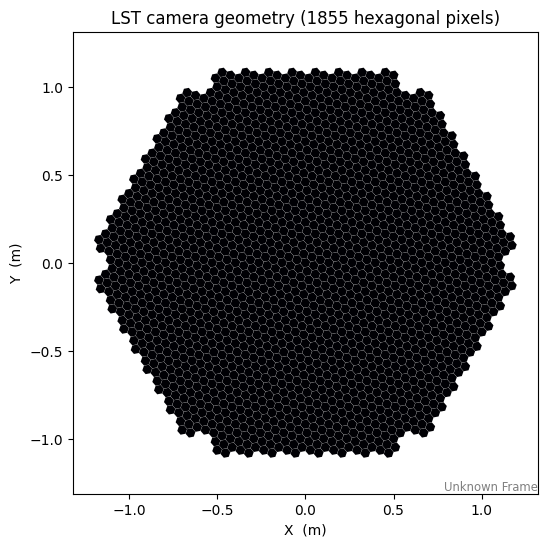

In [2]:
geom = CameraGeometry.from_name("LSTCam")
print(geom)
print("n_pixels:", geom.n_pixels, "| pixel shape:", geom.pix_type,
      "| pixel rotation:", geom.pix_rotation)

fig, ax = plt.subplots(figsize=(6, 6))
disp = CameraDisplay(geom, ax=ax)
disp.image = np.zeros(geom.n_pixels)
ax.set_title("LST camera geometry (1855 hexagonal pixels)")
plt.show()

## 2. Map the hexagonal camera onto a 2-D grid

`keras-hexagdly` (like HexagDLy) works on a 2-D array where the hexagonal
neighbour structure is encoded by an offset-column layout. `GridTransform` finds
the row/column of every camera pixel on that grid.

The original `GridTransform` assumes the camera has *horizontal* neighbour pairs.
The LST camera is rotated ~41°, so it has none — we add a small **auto
de-rotation** step (rotate the pixel coordinates so a neighbour pair becomes
horizontal) before the existing logic. With that, it maps the LST camera with
**zero neighbour mismatches**.

In [3]:
class GridTransform:
    """Map a 1-D hexagonal camera image to a 2-D hexagdly grid.

    Adapted from the SST-1M GridTransform with an auto de-rotation step so it
    also works on rotated cameras (LST, NectarCam, ...).
    """

    def __init__(self, geometry):
        x = geometry.pix_x.value.astype(np.float64)
        y = geometry.pix_y.value.astype(np.float64)
        x, y = self._derotate(x, y, geometry.neighbors)   # <-- the LST fix

        vecs = self._neighbor_vectors(x, y, geometry.neighbors)
        dist = np.linalg.norm(vecs, axis=1)
        horiz = np.abs(vecs[:, 1]) < np.median(dist) * 1e-3
        if not np.any(horiz):
            raise ValueError("no horizontal neighbour vectors after de-rotation")
        horizontal_pitch = np.median(np.abs(vecs[horiz, 0]))
        vertical_pitch = np.median(np.abs(vecs[~horiz, 1]))

        best = None
        for y0 in (0.0, y.max(), y.min()):
            r = np.rint((y - y0) / vertical_pitch).astype(np.int64)
            q = np.rint((x - x.min()) / horizontal_pitch - r / 2).astype(np.int64)
            row, col = self._offset_from_axial(q, r)
            row, col = row - row.min(), col - col.min()
            mc = self._mismatch(geometry, row, col)
            if best is None or mc < best[0]:
                best = (mc, row, col)

        self.neighbor_mismatch_count, self.row_idx, self.col_idx = best
        self.H = int(self.row_idx.max()) + 1
        self.W = int(self.col_idx.max()) + 1
        assert len(set(zip(self.row_idx, self.col_idx))) == geometry.n_pixels

    @staticmethod
    def _neighbor_vectors(x, y, neighbors):
        v = []
        for i, nb in enumerate(neighbors):
            for j in nb:
                if i < j:
                    v.append((x[j] - x[i], y[j] - y[i]))
        return np.asarray(v)

    @classmethod
    def _derotate(cls, x, y, neighbors):
        v = cls._neighbor_vectors(x, y, neighbors)
        # angle that makes a neighbour pair horizontal (fold into one 60deg sector)
        t = np.median(np.arctan2(v[:, 1], v[:, 0]) % (np.pi / 3))
        return x * np.cos(t) + y * np.sin(t), -x * np.sin(t) + y * np.cos(t)

    @staticmethod
    def _offset_from_axial(q, r):
        row = r + np.floor_divide(q - (q & 1), 2)
        return row.astype(np.int64), q.astype(np.int64)

    @staticmethod
    def _hex_neighbors_on_grid(grid, row, col):
        diag = ([(-1, -1), (-1, 1), (0, -1), (0, 1)] if col % 2 == 0
                else [(0, -1), (0, 1), (1, -1), (1, 1)])
        out = []
        for dr, dc in [(-1, 0), (1, 0), *diag]:
            nr, nc = row + dr, col + dc
            if 0 <= nr < grid.shape[0] and 0 <= nc < grid.shape[1] and grid[nr, nc] >= 0:
                out.append(int(grid[nr, nc]))
        return sorted(out)

    @classmethod
    def _mismatch(cls, geometry, row, col):
        grid = np.full((int(row.max()) + 1, int(col.max()) + 1), -1, int)
        for i, (r, c) in enumerate(zip(row, col)):
            if grid[r, c] >= 0:
                return geometry.n_pixels  # collision -> reject this origin
            grid[r, c] = i
        m = 0
        for i, cam_nb in enumerate(geometry.neighbors):
            if cls._hex_neighbors_on_grid(grid, int(row[i]), int(col[i])) != sorted(map(int, cam_nb)):
                m += 1
        return m

    def scatter(self, images):
        """(..., n_pixels) -> (..., H, W), zeros on empty grid cells."""
        out = np.zeros(images.shape[:-1] + (self.H, self.W), np.float32)
        out[..., self.row_idx, self.col_idx] = images
        return out

grid: 47 x 55  |  neighbour mismatches: 0


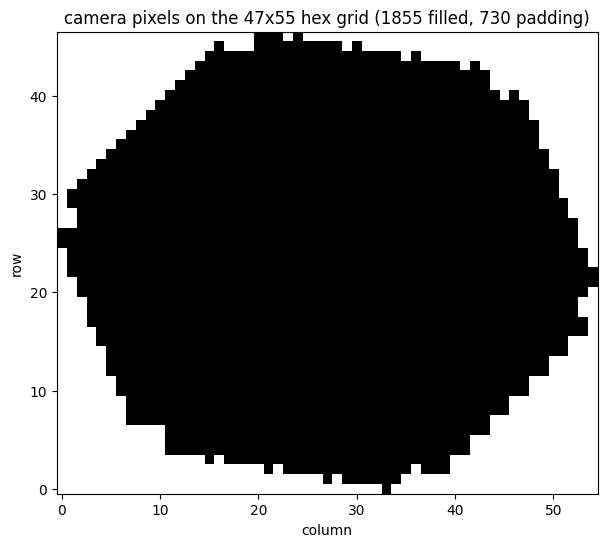

In [4]:
grid = GridTransform(geom)
print(f"grid: {grid.H} x {grid.W}  |  neighbour mismatches: {grid.neighbor_mismatch_count}")

# Show which grid cells are real camera pixels (filled) vs padding (empty).
occupancy = np.zeros((grid.H, grid.W))
occupancy[grid.row_idx, grid.col_idx] = 1
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(occupancy, cmap="Greys", origin="lower")
ax.set_title(f"camera pixels on the {grid.H}x{grid.W} hex grid "
             f"({geom.n_pixels} filled, {grid.H*grid.W-geom.n_pixels} padding)")
ax.set_xlabel("column"); ax.set_ylabel("row")
plt.show()

## 3. Load simulated events (raw waveforms) from the internet

`get_dataset_path(...)` downloads a small public simtel file. We pull every
LST-camera **R1 waveform** — shape `(n_pixels, n_samples)` = `(1855, 30)`, i.e.
the raw time series in each pixel. That temporal axis is what the 3-D conv will
run over.

In [5]:
path = get_dataset_path("gamma_test_large.simtel.gz")
source = EventSource(path, focal_length_choice="EQUIVALENT")
lst_ids = {tid for tid, t in source.subarray.tel.items() if t.camera.name == "LSTCam"}

waveforms = []
for event in source:
    for tid in event.r1.tel:
        if tid in lst_ids and event.r1.tel[tid].waveform is not None:
            wf = np.asarray(event.r1.tel[tid].waveform, np.float32)
            waveforms.append(wf.reshape(geom.n_pixels, -1))   # drop gain axis

X_gamma = np.stack(waveforms)        # (N, n_pixels, n_samples)
N, P, T = X_gamma.shape
print(f"collected {N} LST gamma waveforms, shape per event: ({P} pixels, {T} samples)")

collected 70 LST gamma waveforms, shape per event: (1855 pixels, 30 samples)


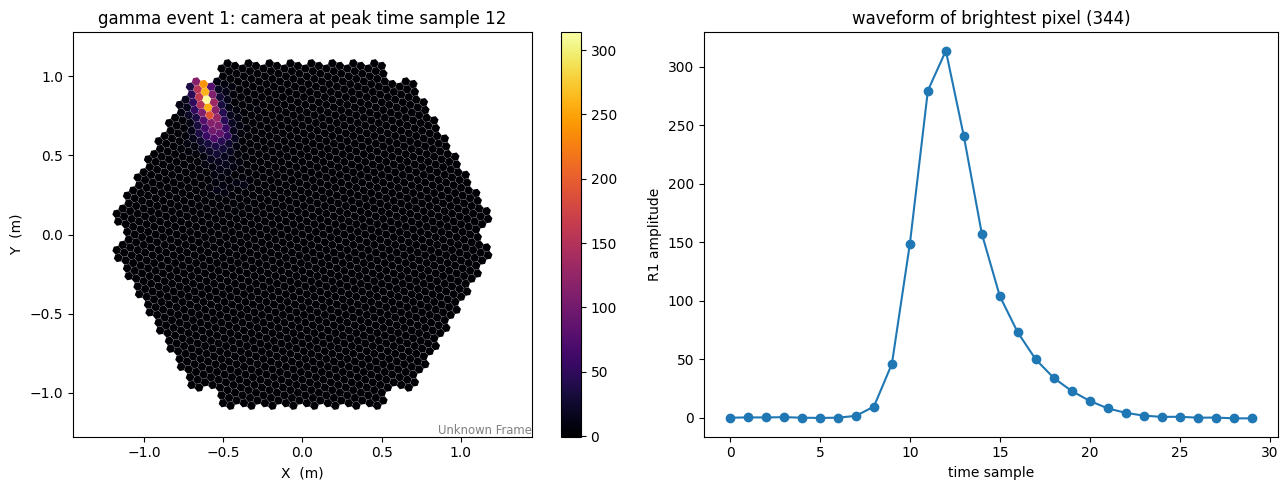

In [6]:
# Look at one gamma event: the camera at its brightest time sample, and the
# time trace of its brightest pixel.
ev = int(np.argmax(X_gamma.max(axis=(1, 2))))     # the most prominent shower
peak_t = int(X_gamma[ev].max(axis=0).argmax())
bright_pix = int(X_gamma[ev, :, peak_t].argmax())

fig, (axc, axt) = plt.subplots(1, 2, figsize=(13, 5))
disp = CameraDisplay(geom, ax=axc)
disp.image = X_gamma[ev, :, peak_t]
disp.add_colorbar()
axc.set_title(f"gamma event {ev}: camera at peak time sample {peak_t}")
axt.plot(X_gamma[ev, bright_pix], marker="o")
axt.set_title(f"waveform of brightest pixel ({bright_pix})")
axt.set_xlabel("time sample"); axt.set_ylabel("R1 amplitude")
plt.tight_layout(); plt.show()

## 4. A night-sky-background noise model (didactic)

The sample data is gamma-only, so we synthesise the **negative class** (pure NSB,
no shower). We estimate a robust pedestal level and fluctuation from the real
waveforms (the vast majority of pixels see only NSB), then:

* **positives** = the real gamma waveforms, each repeated with a few independent
  small NSB realisations added (light data augmentation);
* **negatives** = cameras filled with pure NSB fluctuations at the same pedestal.

Both classes share the same DC level, so the network can't cheat on a constant
offset — it has to find the coherent space-time shower.

> A real analysis would instead use NSB-only / pedestal simtel files (or proton
> showers for gamma/hadron separation). See "Scaling up".

In [7]:
base = float(np.median(X_gamma))
scale = float(1.4826 * np.median(np.abs(X_gamma - base))) or 1.0   # robust sigma
print(f"pedestal base = {base:.3f}, robust scale = {scale:.3f}")

K = 4  # augmentation factor for the gamma class
pos = np.concatenate([
    X_gamma + rng.normal(0, 0.5 * scale, X_gamma.shape).astype(np.float32)
    for _ in range(K)
])
neg = rng.normal(base, scale, pos.shape).astype(np.float32)

X = np.concatenate([pos, neg]).astype(np.float32)
y = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))]).astype(np.float32)
X = (X - base) / scale                      # standardise
perm = rng.permutation(len(X)); X, y = X[perm], y[perm]
print(f"dataset: {X.shape}  |  {int(y.sum())} gamma / {int((1 - y).sum())} noise")

pedestal base = -0.044, robust scale = 0.245


dataset: (560, 1855, 30)  |  280 gamma / 280 noise


## 5. Scatter every time frame onto the hex grid → 3-D volumes

`GridTransform.scatter` places each pixel value at its grid cell. Doing it for
every time sample turns each event into a channels-last volume
`(T, H, W, 1)` — exactly what `keras_hexagdly.Conv3d` expects (depth = time).

volumes: (560, 30, 47, 55, 1) (N, T, H, W, C)


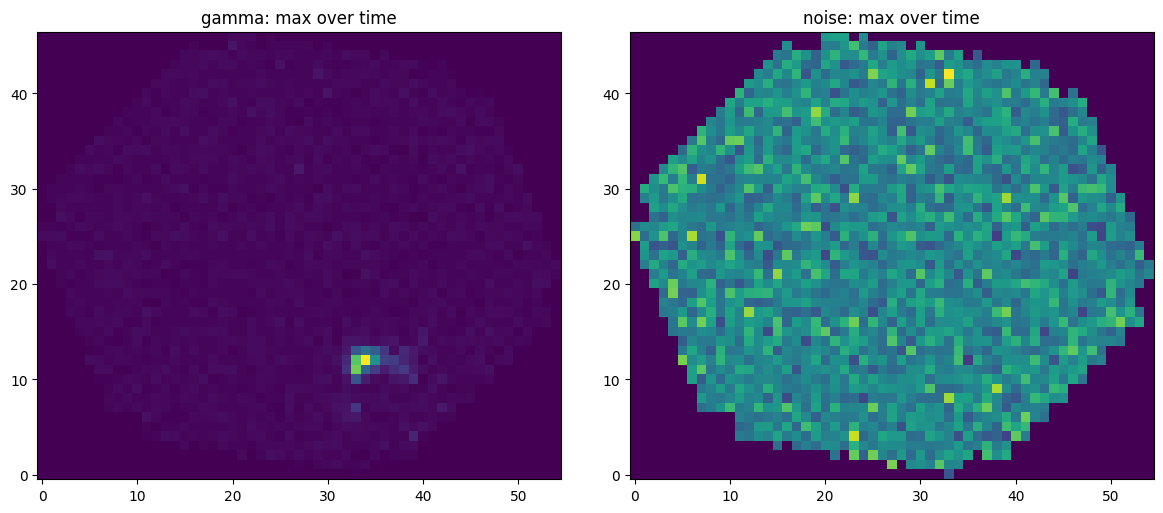

In [8]:
volumes = grid.scatter(X.transpose(0, 2, 1))      # (N, T, n_pix) -> (N, T, H, W)
volumes = volumes[..., None]                       # add channel axis
print("volumes:", volumes.shape, "(N, T, H, W, C)")

# max-over-time projection of one gamma vs one noise sample, on the grid
g_idx = int(np.argmax(y)); n_idx = int(np.argmin(y))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, idx, name in [(axes[0], g_idx, "gamma"), (axes[1], n_idx, "noise")]:
    ax.imshow(volumes[idx, ..., 0].max(axis=0), origin="lower", cmap="viridis")
    ax.set_title(f"{name}: max over time")
plt.tight_layout(); plt.show()

## 6. Build and train the hexagonal 3-D CNN

A small network:

* `hgly.Conv3d` with `kernel_size=(5, 1)` — a temporal window of 5 samples over a
  hex radius-1 neighbourhood (centre + 6 neighbours), `depth_padding="same"` so
  the temporal kernel is centred and the time axis is preserved, and
  `share_neighbors=True` so the 6 neighbours share one weight (fewer params,
  enforced 6-fold symmetry);
* global max over time **and** the whole camera (translation-invariant trigger);
* a small dense head → `P(gamma)`.

In [9]:
model = keras.Sequential([
    keras.layers.Input((T, grid.H, grid.W, 1)),
    hgly.Conv3d(out_channels=8, kernel_size=(5, 1), stride=1, bias=False,
                share_neighbors=True, depth_padding="same"),
    keras.layers.ReLU(),
    keras.layers.GlobalMaxPooling3D(),       # over time AND camera
    keras.layers.BatchNormalization(),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1),                   # logit
])
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3d)                 │ (None, 30, 47, 55, 8)  │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 30, 47, 55, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling3d            │ (None, 8)              │             0 │
│ (GlobalMaxPooling3D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 16 (64.00 B)

In [10]:
history = model.fit(
    volumes, y,
    validation_split=0.2,
    epochs=15,
    batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True)],
    verbose=2,
)

Epoch 1/15


28/28 - 2s - 55ms/step - accuracy: 0.5089 - loss: 0.6861 - val_accuracy: 0.5000 - val_loss: 0.6662


Epoch 2/15


28/28 - 1s - 29ms/step - accuracy: 0.6473 - loss: 0.5440 - val_accuracy: 0.5536 - val_loss: 0.6218


Epoch 3/15


...

28/28 - 1s - 29ms/step - accuracy: 0.9688 - loss: 0.1060 - val_accuracy: 1.0000 - val_loss: 0.3626


Epoch 14/15


28/28 - 1s - 29ms/step - accuracy: 0.9754 - loss: 0.0885 - val_accuracy: 1.0000 - val_loss: 0.3321


Epoch 15/15


28/28 - 1s - 29ms/step - accuracy: 0.9799 - loss: 0.0751 - val_accuracy: 1.0000 - val_loss: 0.3024


## 7. Results

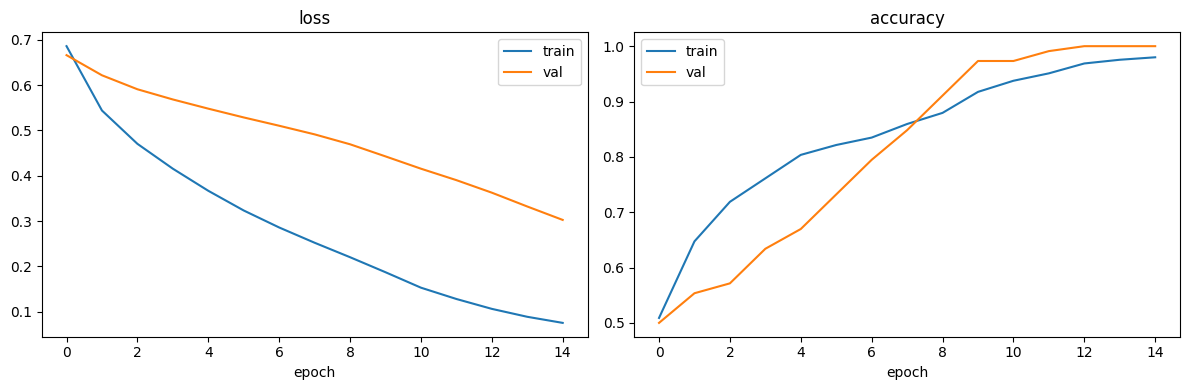

held-out ROC AUC = 1.0000  |  val accuracy = 1.000


In [11]:
# learning curves
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(history.history["loss"], label="train")
a1.plot(history.history["val_loss"], label="val")
a1.set_title("loss"); a1.set_xlabel("epoch"); a1.legend()
a2.plot(history.history["accuracy"], label="train")
a2.plot(history.history["val_accuracy"], label="val")
a2.set_title("accuracy"); a2.set_xlabel("epoch"); a2.legend()
plt.tight_layout(); plt.show()

# held-out ROC AUC (rank-based, no sklearn dependency)
n_val = int(0.2 * len(volumes))
proba = keras.ops.convert_to_numpy(
    keras.ops.sigmoid(model.predict(volumes[-n_val:], verbose=0))).ravel()
yv = y[-n_val:]
order = np.argsort(proba); ranks = np.empty_like(order, float); ranks[order] = np.arange(len(proba))
npos, nneg = yv.sum(), len(yv) - yv.sum()
auc = (ranks[yv == 1].sum() - npos * (npos - 1) / 2) / (npos * nneg)
print(f"held-out ROC AUC = {auc:.4f}  |  val accuracy = {history.history['val_accuracy'][-1]:.3f}")

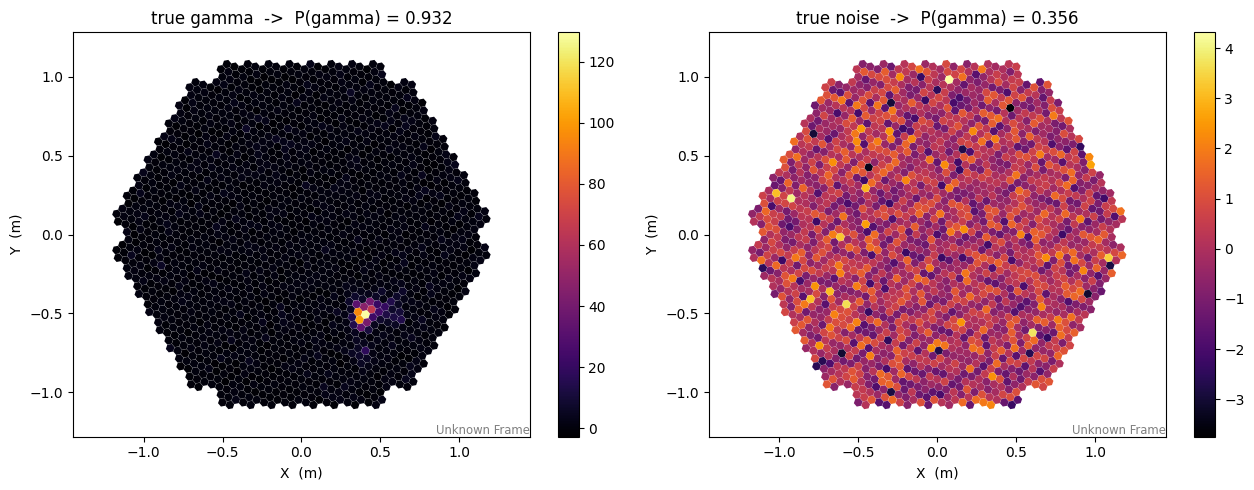

In [12]:
# Show the model's verdict on one gamma and one noise event.
def predict_proba(volume):
    logit = model.predict(volume[None], verbose=0)
    return float(keras.ops.convert_to_numpy(keras.ops.sigmoid(logit)).ravel()[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, idx, name in [(axes[0], g_idx, "true gamma"), (axes[1], n_idx, "true noise")]:
    # un-standardise back to the camera and show the peak-time frame
    cam = volumes[idx, ..., 0]                       # (T, H, W)
    frame = cam[cam.max(axis=(1, 2)).argmax()]       # brightest time frame
    image = np.zeros(geom.n_pixels, np.float32)
    image[:] = frame[grid.row_idx, grid.col_idx]
    disp = CameraDisplay(geom, ax=ax); disp.image = image; disp.add_colorbar()
    ax.set_title(f"{name}  ->  P(gamma) = {predict_proba(volumes[idx]):.3f}")
plt.tight_layout(); plt.show()

## 8. What did the kernels learn?

Because we used `share_neighbors=True` with `kernel_size=(5, 1)`, each output
filter's hexagonal kernel is described by just **two numbers per time step**: a
**centre** weight and one **neighbour-ring** weight (shared by all 6 neighbours).
So we can read off exactly what each of the 8 filters learned — first the
**temporal profile** (centre vs ring across the 5-sample window), then the
**spatial hex kernel** at each filter's most active time step.

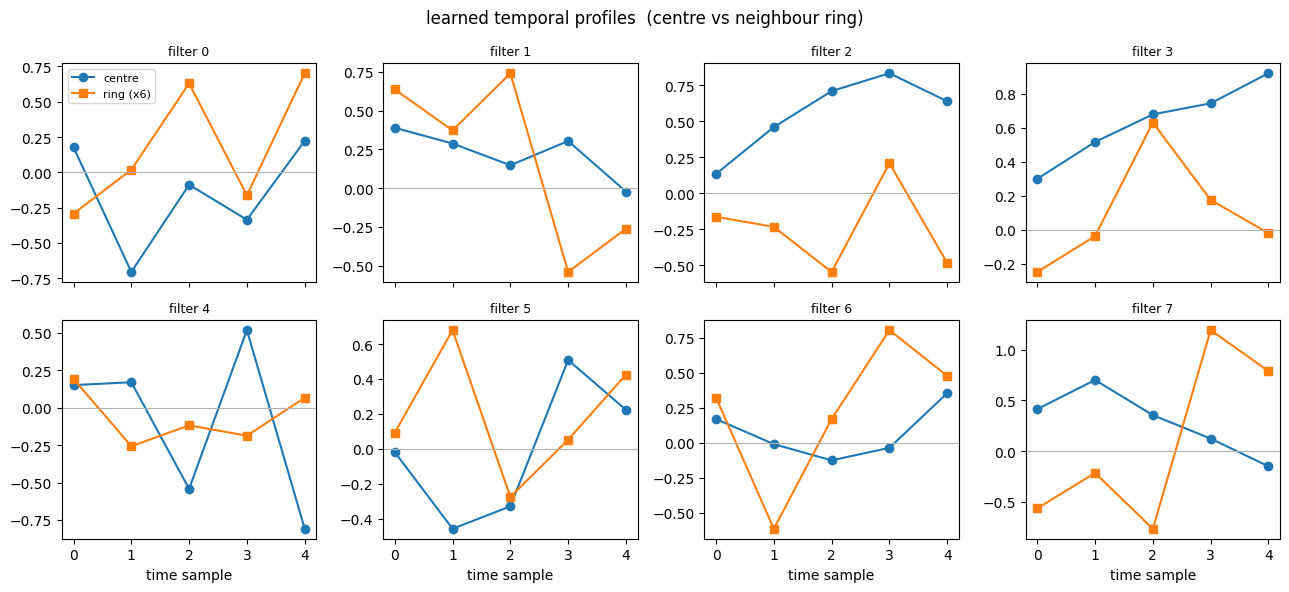

In [13]:
conv = model.layers[0]                                  # the hgly.Conv3d layer
rw = keras.ops.convert_to_numpy(conv.ring_weights)     # (depth, num_rings, in, out)
center = rw[:, 0, 0, :]      # (depth, F) centre-cell weight per time step / filter
ring = rw[:, 1, 0, :]        # (depth, F) shared neighbour-ring weight
depth, F = center.shape

fig, axes = plt.subplots(2, 4, figsize=(13, 6), sharex=True)
for f, ax in enumerate(axes.ravel()):
    ax.plot(center[:, f], "-o", label="centre")
    ax.plot(ring[:, f], "-s", label="ring (x6)")
    ax.axhline(0, color="0.7", lw=0.8)
    ax.set_title(f"filter {f}", fontsize=9)
    if f == 0:
        ax.legend(fontsize=8)
    if f >= 4:
        ax.set_xlabel("time sample")
fig.suptitle("learned temporal profiles  (centre vs neighbour ring)")
plt.tight_layout(); plt.show()

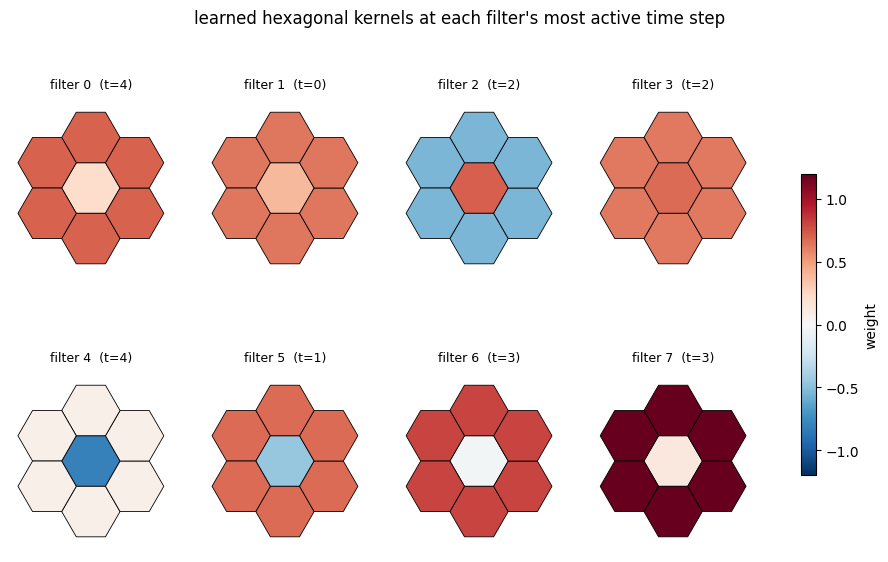

In [14]:
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection

# a 7-cell flat-top hex cluster: centre + 6 neighbours
_OFF = [(0, 0), (0, -1), (0.866, -0.5), (0.866, 0.5), (0, 1), (-0.866, 0.5), (-0.866, -0.5)]

def draw_hex_kernel(ax, center_w, ring_w, vmax, title=""):
    hexes = [RegularPolygon((x, y), 6, radius=0.577, orientation=np.pi / 6) for x, y in _OFF]
    pc = PatchCollection(hexes, cmap="RdBu_r", edgecolor="k", linewidth=0.6)
    pc.set_array(np.array([center_w] + [ring_w] * 6))   # centre + 6 shared neighbours
    pc.set_clim(-vmax, vmax)
    ax.add_collection(pc)
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.8, 1.8)
    ax.set_aspect("equal"); ax.set_axis_off(); ax.set_title(title, fontsize=9)
    return pc

peak_t = np.abs(rw).sum(axis=1).squeeze(1).argmax(axis=0)   # most active time per filter
vmax = float(np.abs(rw).max())
fig, axes = plt.subplots(2, 4, figsize=(12, 6.5))
for f, ax in enumerate(axes.ravel()):
    t = int(peak_t[f])
    pc = draw_hex_kernel(ax, center[t, f], ring[t, f], vmax, f"filter {f}  (t={t})")
fig.colorbar(pc, ax=axes, shrink=0.6, label="weight")
fig.suptitle("learned hexagonal kernels at each filter's most active time step")
plt.show()

## Scaling up (for real work)

This notebook is intentionally small and self-contained. To turn it into a real
analysis:

* **More data.** The public sample file has ~70 LST events. Point `EventSource`
  at full production simtel files (or many of them) for tens of thousands of
  events. The collection loop is unchanged.
* **A real negative class.** Replace the synthetic NSB with **pedestal / NSB-only
  simtel files** (true trigger background), or use **proton showers** for genuine
  gamma/hadron separation — the harder, physically interesting task.
* **Calibrate** if you want photo-electron units: run ctapipe's `CameraCalibrator`
  and use `event.dl1.tel[tid].image` (integrated) or keep the waveform for the
  temporal model, as here.
* **Any hexagonal camera.** Swap `"LSTCam"` for `"NectarCam"`, `"FlashCam"`,
  `"MAGICCam"`, ... — `GridTransform` handles the rotation automatically.
* **Bigger model.** Stack `hgly.Conv3d` + `hgly.MaxPool3d` blocks, add more
  filters, try `share_neighbors=False` for a full kernel, or `kernel_size=(5, 2)`
  for a radius-2 hex neighbourhood.
* **Performance.** Wrap inference/training in a compiled call (`model.fit` /
  `model.predict` already do) — the hexagonal conv is much faster compiled than
  eager (see the keras-hexagdly benchmarks).

See [keras-hexagdly](https://github.com/YugnatD/keras-hexagdly) for the layer API
and more examples.